## COMPAS snapshot benchmark

It compares, on **COMPAS**:

- `LinUCB`
- `GroupAwareDPLinUCB`
- `LogisticRegression`
- `RandomForest`

across multiple training horizons:

- `50`
- `100`
- `250`
- `500`

for both sensitive attributes:

- `sex`
- `race_binary`

and both preprocessing strategies:

- `uniform`
- `reweigh_group_label`

In [1]:
from pathlib import Path
from typing import Any
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from fair_bandits.config import build_config
from fair_bandits.data import (
    load_compas,
    clean_compas_minimal,
    ensure_compas_race_binary,
    compas_reward_from_recid,
    make_group_label_sampling_probs,
)
from fair_bandits.metrics import summarize_metrics, mean_ci
from fair_bandits.policies import LinUCB, GroupAwareDPLinUCB
from fair_bandits.experiments import compare_methods

In [2]:
CFG = build_config("full")   # switch to "full" for thesis runs

DATASET_NAME = "compas"
SENSITIVE_COLS = ["sex", "race_binary"]
PREPROCESSINGS = ["uniform", "reweigh_group_label"]
HORIZONS = [50, 100, 250, 500]
SEEDS = [CFG.seed0 + i for i in range(max(5, CFG.n_seeds))]

TEST_SIZE = 0.30
RUN_MISSING = True

METHOD_ORDER = [
    "LinUCB",
    "GroupAwareDPLinUCB",
    "LogisticRegression",
    "RandomForest",
]

BENCHMARK_METRICS = [
    "accuracy",
    "DP_gap",
    "TPR_gap",
    "FPR_gap",
    "EO_gap",
    "PPV_gap",
    "UtilityGap",
    "CumulativeRegret",
]

RESULTS_DIR = CFG.results_dir / "compas_snapshot_benchmark"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CFG

ExperimentConfig(run_mode='full', seed0=42, cache_dir=WindowsPath('data_cache'), results_dir=WindowsPath('results/full'), T_group_bandit=50000, T_contextual=30000, n_seeds=50, delta_fair=0.05, alpha_linucb=1.5, lambda_ridge=1.0, dp_tau=0.02, dp_lambda=2.0, beta_smooth=1.0, min_group_count=20, compas_hash_features=512, n_bootstrap=1000)

### Load and clean COMPAS

In [3]:
df_raw = load_compas(cache_dir=CFG.cache_dir)
df_raw = clean_compas_minimal(df_raw)
df_raw = ensure_compas_race_binary(df_raw)

print("Shape after cleaning:", df_raw.shape)
display(df_raw.head())

Shape after cleaning: (7214, 10)


,sex,race,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid,race_binary
0,Male,Other,69,0,0,0,0,F,0,Non-White
1,Male,African-American,34,0,0,0,0,F,1,Non-White
2,Male,African-American,24,0,0,1,4,F,1,Non-White
3,Male,African-American,23,0,1,0,1,F,0,Non-White
4,Male,Other,43,0,0,0,2,F,0,Non-White


### Leakage-aware benchmark helpers

In [4]:
def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def _compas_feature_columns_for_benchmark(df: pd.DataFrame, sensitive_col: str) -> list[str]:
    cols = [c for c in df.columns if c != "two_year_recid"]

    drop_cols = {sensitive_col}
    if sensitive_col == "race_binary":
        drop_cols.add("race")
    if sensitive_col == "race":
        drop_cols.add("race_binary")

    return [c for c in cols if c not in drop_cols]


def prepare_compas_benchmark_split(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    sensitive_col: str = "sex",
):
    train_df = ensure_compas_race_binary(clean_compas_minimal(train_df.copy()))
    test_df = ensure_compas_race_binary(clean_compas_minimal(test_df.copy()))

    if sensitive_col not in train_df.columns or sensitive_col not in test_df.columns:
        raise ValueError(f"Sensitive column '{sensitive_col}' not available in COMPAS data.")

    feature_cols = _compas_feature_columns_for_benchmark(train_df, sensitive_col=sensitive_col)

    X_train_df = train_df[feature_cols].copy()
    X_test_df = test_df[feature_cols].copy()

    y_train = compas_reward_from_recid(train_df["two_year_recid"])
    y_test = compas_reward_from_recid(test_df["two_year_recid"])

    group_train = train_df[sensitive_col].astype(str).fillna("Unknown").to_numpy()
    group_test = test_df[sensitive_col].astype(str).fillna("Unknown").to_numpy()

    num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train_df[c])]
    cat_cols = [c for c in feature_cols if c not in num_cols]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", _make_ohe()),
    ])

    preproc = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
    )

    X_train = preproc.fit_transform(X_train_df)
    X_test = preproc.transform(X_test_df)

    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)

    meta = {
        "feature_cols": feature_cols,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "n_train": int(X_train.shape[0]),
        "n_test": int(X_test.shape[0]),
        "n_features_after_encoding": int(X_train.shape[1]),
        "sensitive_col": sensitive_col,
    }
    return X_train, X_test, y_train, y_test, group_train, group_test, meta


def fit_bandit_policy_on_prefix(
    X_train: np.ndarray,
    y_train: np.ndarray,
    group_train: np.ndarray,
    idx_prefix: np.ndarray,
    method_name: str,
    cfg,
):
    d = int(X_train.shape[1])

    if method_name == "LinUCB":
        policy = LinUCB(d=d, alpha=cfg.alpha_linucb, lam=cfg.lambda_ridge)
    elif method_name == "GroupAwareDPLinUCB":
        policy = GroupAwareDPLinUCB(
            d=d,
            groups=group_train,
            alpha=cfg.alpha_linucb,
            lam=cfg.lambda_ridge,
            tau=cfg.dp_tau,
            lambda_fair=cfg.dp_lambda,
            beta_smooth=cfg.beta_smooth,
            min_group_count=cfg.min_group_count,
        )
    else:
        raise ValueError(f"Unsupported bandit method: {method_name}")

    for i in idx_prefix:
        x = X_train[int(i)]
        yt = int(y_train[int(i)])
        g = str(group_train[int(i)])

        action = int(policy.select(x, g))
        reward = float(action == yt)
        policy.update(x, action, reward, g)

    return policy


def predict_with_bandit_policy(policy, X_test: np.ndarray, group_test: np.ndarray) -> np.ndarray:
    preds = []
    for x, g in zip(X_test, group_test):
        preds.append(int(policy.select(x, str(g))))
    return np.asarray(preds, dtype=int)


def fit_supervised_prefix_model(
    X_prefix: np.ndarray,
    y_prefix: np.ndarray,
    method_name: str,
    seed: int,
):
    y_prefix = np.asarray(y_prefix, dtype=int)

    if np.unique(y_prefix).size < 2:
        clf = DummyClassifier(strategy="constant", constant=int(y_prefix[0]))
        clf.fit(X_prefix, y_prefix)
        return clf

    if method_name == "LogisticRegression":
        clf = LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            random_state=seed,
        )
    elif method_name == "RandomForest":
        clf = RandomForestClassifier(
            n_estimators=400,
            random_state=seed,
            n_jobs=-1,
        )
    else:
        raise ValueError(f"Unsupported supervised method: {method_name}")

    clf.fit(X_prefix, y_prefix)
    return clf


def evaluate_predictions_to_long_rows(
    *,
    dataset: str,
    sensitive: str,
    preprocessing: str,
    horizon: int,
    seed: int,
    method: str,
    y_true: np.ndarray,
    y_hat: np.ndarray,
    group: np.ndarray,
):
    reward = (np.asarray(y_true, dtype=int) == np.asarray(y_hat, dtype=int)).astype(float)
    met = summarize_metrics(
        y_true=np.asarray(y_true, dtype=int),
        y_hat=np.asarray(y_hat, dtype=int),
        group=np.asarray(group).astype(str),
        reward=reward,
        oracle_reward=1.0,
    )

    rows = []
    for metric in BENCHMARK_METRICS:
        rows.append({
            "dataset": dataset,
            "sensitive": sensitive,
            "preprocessing": preprocessing,
            "horizon": int(horizon),
            "seed": int(seed),
            "method": method,
            "metric": metric,
            "value": float(met[metric]),
            "n_eval": int(len(y_true)),
        })
    return rows


def summarize_long_with_ci(long_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["dataset", "sensitive", "preprocessing", "horizon", "method", "metric"]
    for keys, sub in long_df.groupby(group_cols):
        mu, lo, hi = mean_ci(sub["value"].to_numpy(dtype=float), alpha=0.05)
        rows.append({
            **dict(zip(group_cols, keys)),
            "mean": mu,
            "ci_low": lo,
            "ci_high": hi,
            "n_seeds": int(sub["seed"].nunique()),
        })
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


def run_compas_snapshot_benchmark(
    *,
    df_raw: pd.DataFrame,
    cfg,
    methods_to_run: list[str],
    sensitive_list: list[str],
    preprocessing_modes: list[str],
    horizons: list[int],
    seeds: list[int],
    verbose: bool = False,
):
    rows = []

    required_methods = set(methods_to_run)
    valid_methods = {"LinUCB", "GroupAwareDPLinUCB", "LogisticRegression", "RandomForest"}
    unknown = required_methods - valid_methods
    if unknown:
        raise ValueError(f"Unknown methods_to_run: {sorted(unknown)}")

    df_src = ensure_compas_race_binary(clean_compas_minimal(df_raw.copy()))
    y_for_split = compas_reward_from_recid(df_src["two_year_recid"])

    for sensitive in sensitive_list:
        if sensitive not in df_src.columns:
            raise ValueError(f"Sensitive column '{sensitive}' not found in dataframe.")

        for preprocessing in preprocessing_modes:
            for seed in seeds:
                train_df, test_df = train_test_split(
                    df_src,
                    test_size=TEST_SIZE,
                    random_state=int(seed),
                    stratify=y_for_split,
                )

                X_train, X_test, y_train, y_test, group_train, group_test, meta = prepare_compas_benchmark_split(
                    train_df=train_df,
                    test_df=test_df,
                    sensitive_col=sensitive,
                )

                sampling_probs = None
                if preprocessing == "reweigh_group_label":
                    sampling_probs = make_group_label_sampling_probs(group_train, y_train)

                if verbose:
                    print(
                        f"[seed={seed}] sensitive={sensitive} preprocessing={preprocessing} "
                        f"train={X_train.shape} test={X_test.shape}"
                    )

                for horizon in horizons:
                    rng = np.random.default_rng(int(seed))
                    idx_prefix = rng.choice(
                        len(X_train),
                        size=int(horizon),
                        replace=True,
                        p=sampling_probs,
                    )

                    X_prefix = X_train[idx_prefix]
                    y_prefix = y_train[idx_prefix]
                    group_prefix = group_train[idx_prefix]

                    for method in methods_to_run:
                        if method in {"LinUCB", "GroupAwareDPLinUCB"}:
                            policy = fit_bandit_policy_on_prefix(
                                X_train=X_train,
                                y_train=y_train,
                                group_train=group_train,
                                idx_prefix=idx_prefix,
                                method_name=method,
                                cfg=cfg,
                            )
                            y_hat = predict_with_bandit_policy(policy, X_test, group_test)
                        else:
                            clf = fit_supervised_prefix_model(
                                X_prefix=X_prefix,
                                y_prefix=y_prefix,
                                method_name=method,
                                seed=int(seed),
                            )
                            y_hat = clf.predict(X_test).astype(int)

                        rows.extend(
                            evaluate_predictions_to_long_rows(
                                dataset=DATASET_NAME,
                                sensitive=sensitive,
                                preprocessing=preprocessing,
                                horizon=horizon,
                                seed=int(seed),
                                method=method,
                                y_true=y_test,
                                y_hat=y_hat,
                                group=group_test,
                            )
                        )

    perseed_long = pd.DataFrame(rows).sort_values(
        ["dataset", "sensitive", "preprocessing", "horizon", "seed", "method", "metric"]
    ).reset_index(drop=True)

    ci_long = summarize_long_with_ci(perseed_long)

    friedman_frames = []
    pairwise_frames = []

    lower_is_better_metrics = {"DP_gap", "TPR_gap", "FPR_gap", "EO_gap", "PPV_gap", "UtilityGap", "CumulativeRegret"}

    for metric in perseed_long["metric"].dropna().unique().tolist():
        sub = perseed_long[perseed_long["metric"] == metric].copy()
        friedman_df, pairwise_df = compare_methods(
            sub,
            value_col="value",
            method_col="method",
            seed_col="seed",
            group_cols=["dataset", "sensitive", "preprocessing", "horizon", "metric"],
            lower_is_better=(metric in lower_is_better_metrics),
        )
        if not friedman_df.empty:
            friedman_frames.append(friedman_df)
        if not pairwise_df.empty:
            pairwise_frames.append(pairwise_df)

    friedman_all = (
        pd.concat(friedman_frames, ignore_index=True)
        if friedman_frames else pd.DataFrame()
    )
    pairwise_all = (
        pd.concat(pairwise_frames, ignore_index=True)
        if pairwise_frames else pd.DataFrame()
    )

    return perseed_long, ci_long, friedman_all, pairwise_all

### Run benchmark or load cached results

In [5]:
perseed_path = RESULTS_DIR / "compas_snapshot_perseed_long.csv"
ci_path = RESULTS_DIR / "compas_snapshot_ci_long.csv"
friedman_path = RESULTS_DIR / "compas_snapshot_friedman.csv"
pairwise_path = RESULTS_DIR / "compas_snapshot_pairwise_df.csv"

if RUN_MISSING or not (perseed_path.exists() and ci_path.exists() and pairwise_path.exists()):
    snapshot_perseed_long, snapshot_ci_long, snapshot_friedman_df, snapshot_pairwise_df = run_compas_snapshot_benchmark(
        df_raw=df_raw,
        cfg=CFG,
        methods_to_run=METHOD_ORDER,
        sensitive_list=SENSITIVE_COLS,
        preprocessing_modes=PREPROCESSINGS,
        horizons=HORIZONS,
        seeds=SEEDS,
        verbose=False,
    )

    snapshot_perseed_long.to_csv(perseed_path, index=False)
    snapshot_ci_long.to_csv(ci_path, index=False)
    snapshot_friedman_df.to_csv(friedman_path, index=False)
    snapshot_pairwise_df.to_csv(pairwise_path, index=False)
    print("Saved snapshot benchmark outputs to:")
    print(" ", perseed_path.resolve())
    print(" ", ci_path.resolve())
    print(" ", friedman_path.resolve())
    print(" ", pairwise_path.resolve())
else:
    snapshot_perseed_long = pd.read_csv(perseed_path)
    snapshot_ci_long = pd.read_csv(ci_path)
    snapshot_friedman_df = pd.read_csv(friedman_path) if friedman_path.exists() else pd.DataFrame()
    snapshot_pairwise_df = pd.read_csv(pairwise_path)
    print("Loaded cached snapshot benchmark outputs from:")
    print(" ", perseed_path.resolve())

Saved snapshot benchmark outputs to:
  C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\notebooks\results\full\compas_snapshot_benchmark\compas_snapshot_perseed_long.csv
  C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\notebooks\results\full\compas_snapshot_benchmark\compas_snapshot_ci_long.csv
  C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\notebooks\results\full\compas_snapshot_benchmark\compas_snapshot_friedman.csv
  C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\notebooks\results\full\compas_snapshot_benchmark\compas_snapshot_pairwise_df.csv


In [6]:
print("Shapes:")
print("  snapshot_perseed_long:", snapshot_perseed_long.shape)
print("  snapshot_ci_long     :", snapshot_ci_long.shape)
print("  snapshot_friedman_df :", snapshot_friedman_df.shape)
print("  snapshot_pairwise_df :", snapshot_pairwise_df.shape)

display(snapshot_ci_long.head(24))
display(snapshot_pairwise_df.head(24))

Shapes:
  snapshot_perseed_long: (25600, 9)
  snapshot_ci_long     : (512, 10)
  snapshot_friedman_df : (128, 11)
  snapshot_pairwise_df : (768, 16)


,dataset,sensitive,preprocessing,horizon,method,metric,mean,ci_low,ci_high,n_seeds
0,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,CumulativeRegret,893.160000,727.625000,1083.775000,50
1,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,DP_gap,0.124829,0.005536,0.354717,50
2,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,EO_gap,0.145291,0.015814,0.360812,50
3,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,FPR_gap,0.126476,0.003470,0.317029,50
4,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,PPV_gap,0.073901,0.013639,0.141068,50
5,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,TPR_gap,0.122659,0.010913,0.360812,50
6,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,UtilityGap,0.030638,0.001372,0.101754,50
7,compas,race_binary,reweigh_group_label,50,GroupAwareDPLinUCB,accuracy,0.587455,0.499411,0.663915,50
8,compas,race_binary,reweigh_group_label,50,LinUCB,CumulativeRegret,891.340000,731.700000,1087.100000,50
9,compas,race_binary,reweigh_group_label,50,LinUCB,DP_gap,0.105484,0.006149,0.179457,50


,dataset,sensitive,preprocessing,horizon,metric,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,LinUCB,50,893.16,891.34,1.82,382.5,7.116042e-01,LinUCB,1.000000e+00
1,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,LogisticRegression,50,893.16,850.16,43.00,242.0,1.345230e-04,LogisticRegression,5.380920e-04
2,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,RandomForest,50,893.16,899.38,-6.22,570.0,5.146469e-01,GroupAwareDPLinUCB,1.000000e+00
3,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LinUCB,LogisticRegression,50,891.34,850.16,41.18,216.5,4.818853e-05,LogisticRegression,2.409426e-04
4,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LinUCB,RandomForest,50,891.34,899.38,-8.04,549.0,5.275905e-01,LinUCB,1.000000e+00
5,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LogisticRegression,RandomForest,50,850.16,899.38,-49.22,189.5,1.525344e-05,LogisticRegression,9.152065e-05
6,compas,race_binary,reweigh_group_label,100,CumulativeRegret,value,GroupAwareDPLinUCB,LinUCB,50,853.86,851.08,2.78,416.5,2.541739e-01,LinUCB,2.541739e-01
7,compas,race_binary,reweigh_group_label,100,CumulativeRegret,value,GroupAwareDPLinUCB,LogisticRegression,50,853.86,819.92,33.94,227.5,7.556359e-05,LogisticRegression,3.778180e-04
8,compas,race_binary,reweigh_group_label,100,CumulativeRegret,value,GroupAwareDPLinUCB,RandomForest,50,853.86,877.16,-23.30,334.0,5.596858e-03,GroupAwareDPLinUCB,1.193463e-02
9,compas,race_binary,reweigh_group_label,100,CumulativeRegret,value,LinUCB,LogisticRegression,50,851.08,819.92,31.16,255.0,6.360278e-04,LogisticRegression,2.544111e-03


### Final-horizon summary table

In [7]:
final_horizon = max(HORIZONS)
final_table = snapshot_ci_long[
    snapshot_ci_long["horizon"] == final_horizon
].copy()

final_table["mean_ci"] = final_table.apply(
    lambda r: f"{r['mean']:.3f} [{r['ci_low']:.3f}, {r['ci_high']:.3f}]",
    axis=1,
)

final_pivot = (
    final_table
    .pivot_table(
        index=["dataset", "sensitive", "preprocessing", "metric"],
        columns="method",
        values="mean_ci",
        aggfunc="first",
    )
    .reset_index()
    .sort_values(["sensitive", "preprocessing", "metric"])
    .reset_index(drop=True)
)

display(final_pivot)

method,dataset,sensitive,preprocessing,metric,GroupAwareDPLinUCB,LinUCB,LogisticRegression,RandomForest
0,compas,race_binary,reweigh_group_label,CumulativeRegret,"748.120 [686.350, 843.225]","747.160 [693.125, 840.675]","752.260 [695.450, 812.000]","871.320 [823.450, 921.775]"
1,compas,race_binary,reweigh_group_label,DP_gap,"0.100 [0.015, 0.194]","0.183 [0.139, 0.225]","0.188 [0.158, 0.228]","0.115 [0.079, 0.164]"
2,compas,race_binary,reweigh_group_label,EO_gap,"0.115 [0.025, 0.201]","0.192 [0.142, 0.252]","0.197 [0.156, 0.263]","0.122 [0.072, 0.179]"
3,compas,race_binary,reweigh_group_label,FPR_gap,"0.108 [0.017, 0.201]","0.190 [0.110, 0.252]","0.194 [0.146, 0.263]","0.121 [0.072, 0.179]"
4,compas,race_binary,reweigh_group_label,PPV_gap,"0.035 [0.001, 0.094]","0.020 [0.002, 0.049]","0.020 [0.002, 0.057]","0.043 [0.012, 0.088]"
5,compas,race_binary,reweigh_group_label,TPR_gap,"0.067 [0.005, 0.147]","0.132 [0.075, 0.196]","0.138 [0.096, 0.195]","0.081 [0.038, 0.126]"
6,compas,race_binary,reweigh_group_label,UtilityGap,"0.022 [0.002, 0.057]","0.014 [0.001, 0.038]","0.014 [0.002, 0.043]","0.014 [0.000, 0.043]"
7,compas,race_binary,reweigh_group_label,accuracy,"0.654 [0.611, 0.683]","0.655 [0.612, 0.680]","0.653 [0.625, 0.679]","0.598 [0.574, 0.620]"
8,compas,race_binary,uniform,CumulativeRegret,"731.100 [695.225, 779.550]","722.600 [684.675, 778.325]","720.620 [685.675, 760.775]","843.820 [780.925, 899.650]"
9,compas,race_binary,uniform,DP_gap,"0.075 [0.001, 0.184]","0.164 [0.119, 0.212]","0.161 [0.122, 0.204]","0.115 [0.074, 0.165]"


### Horizon plots

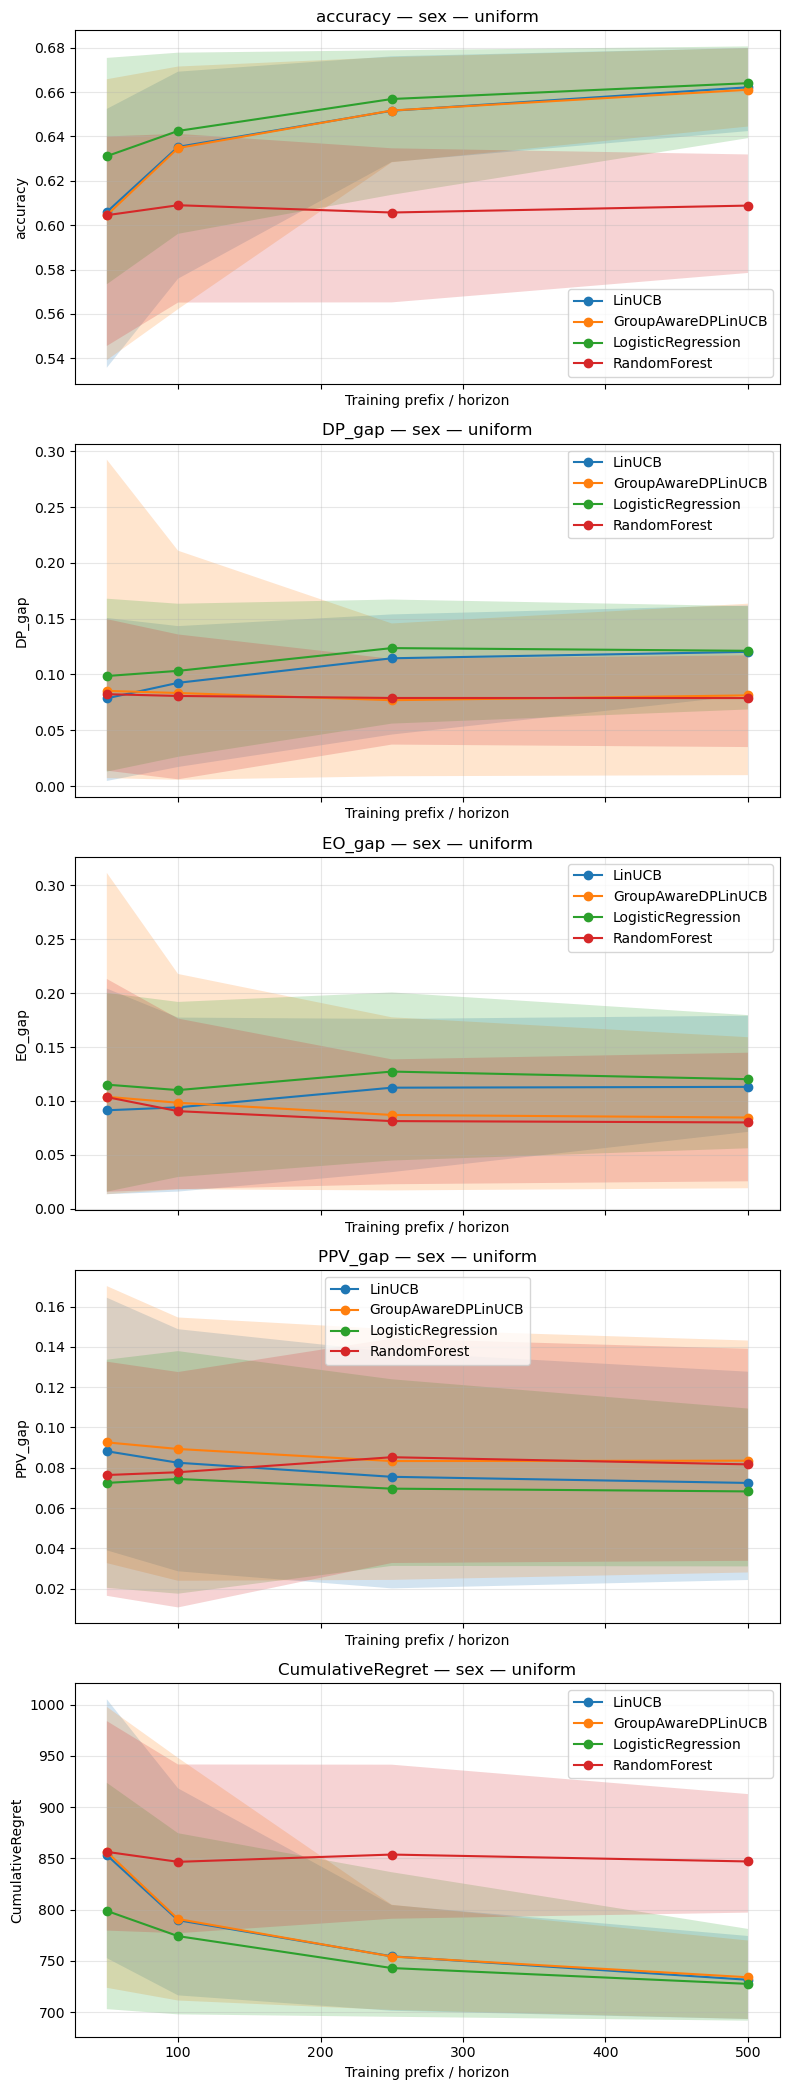

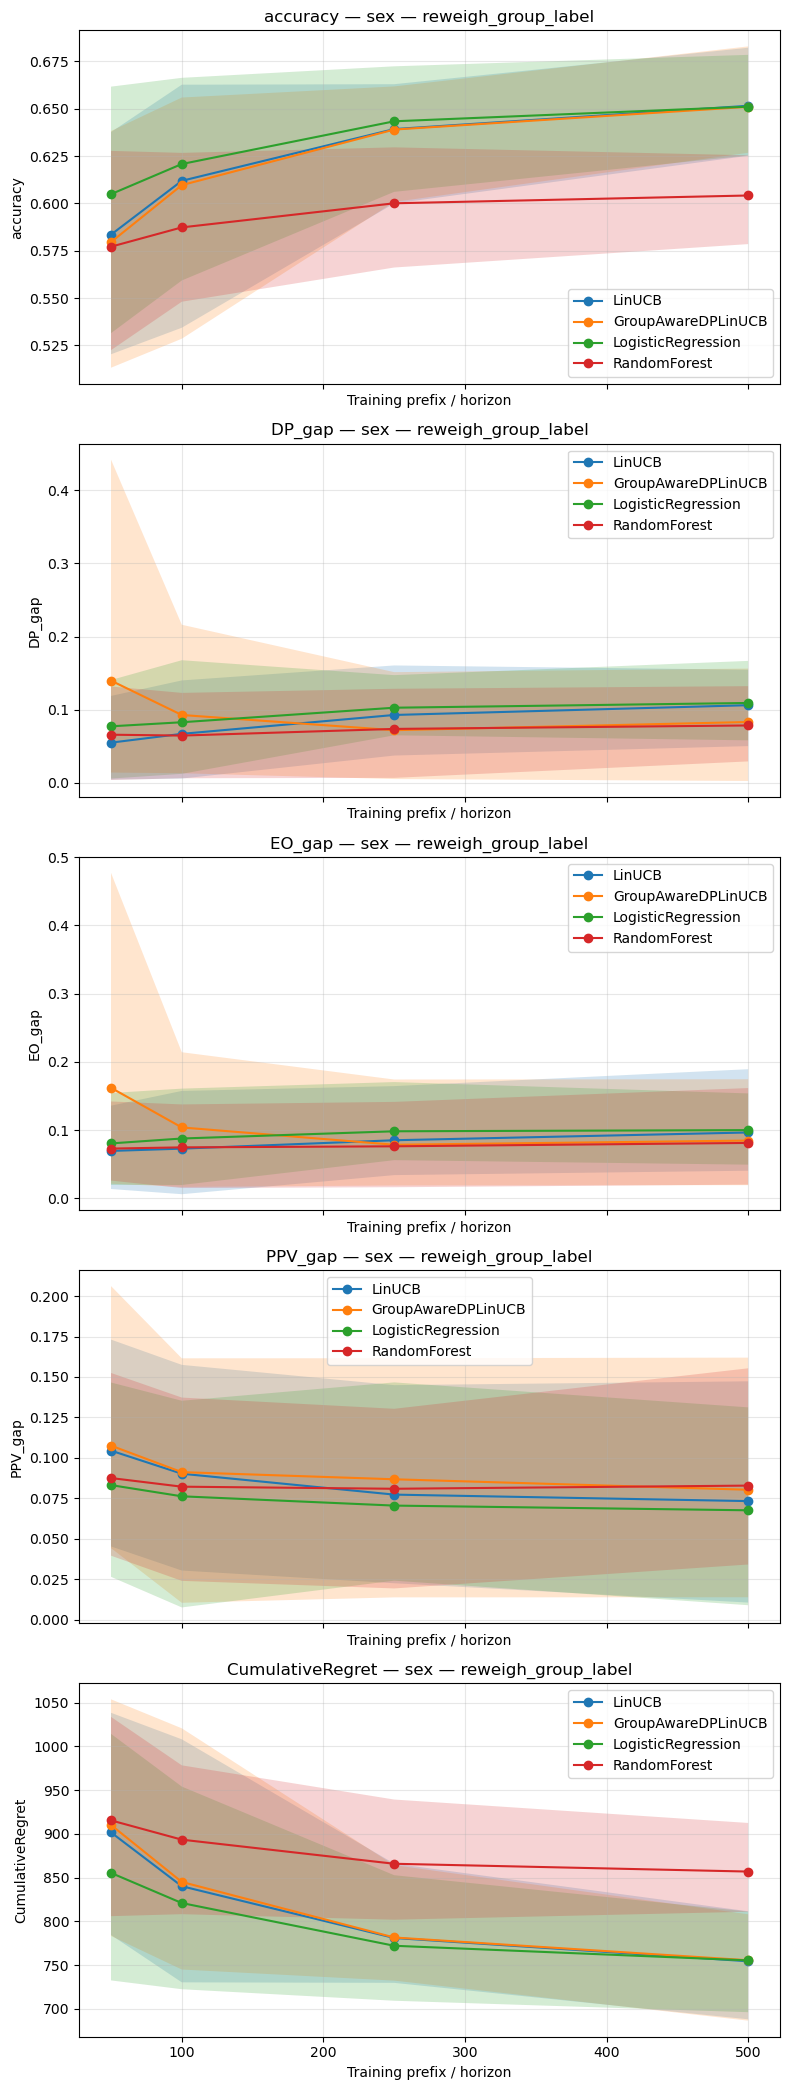

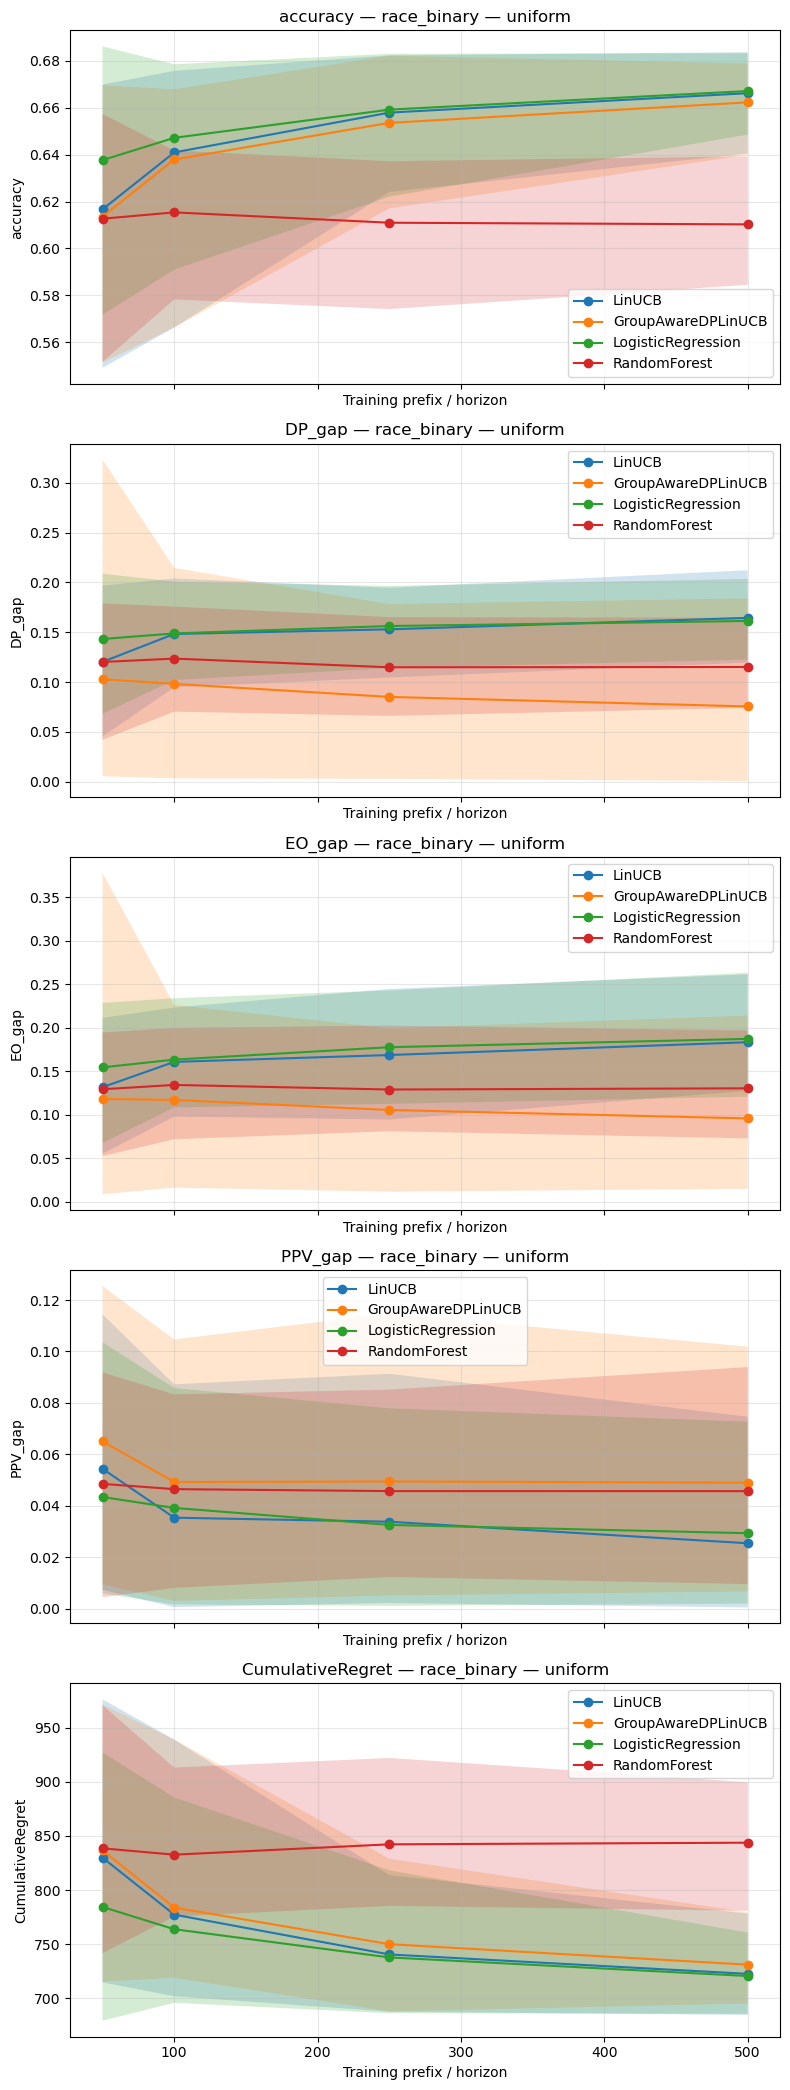

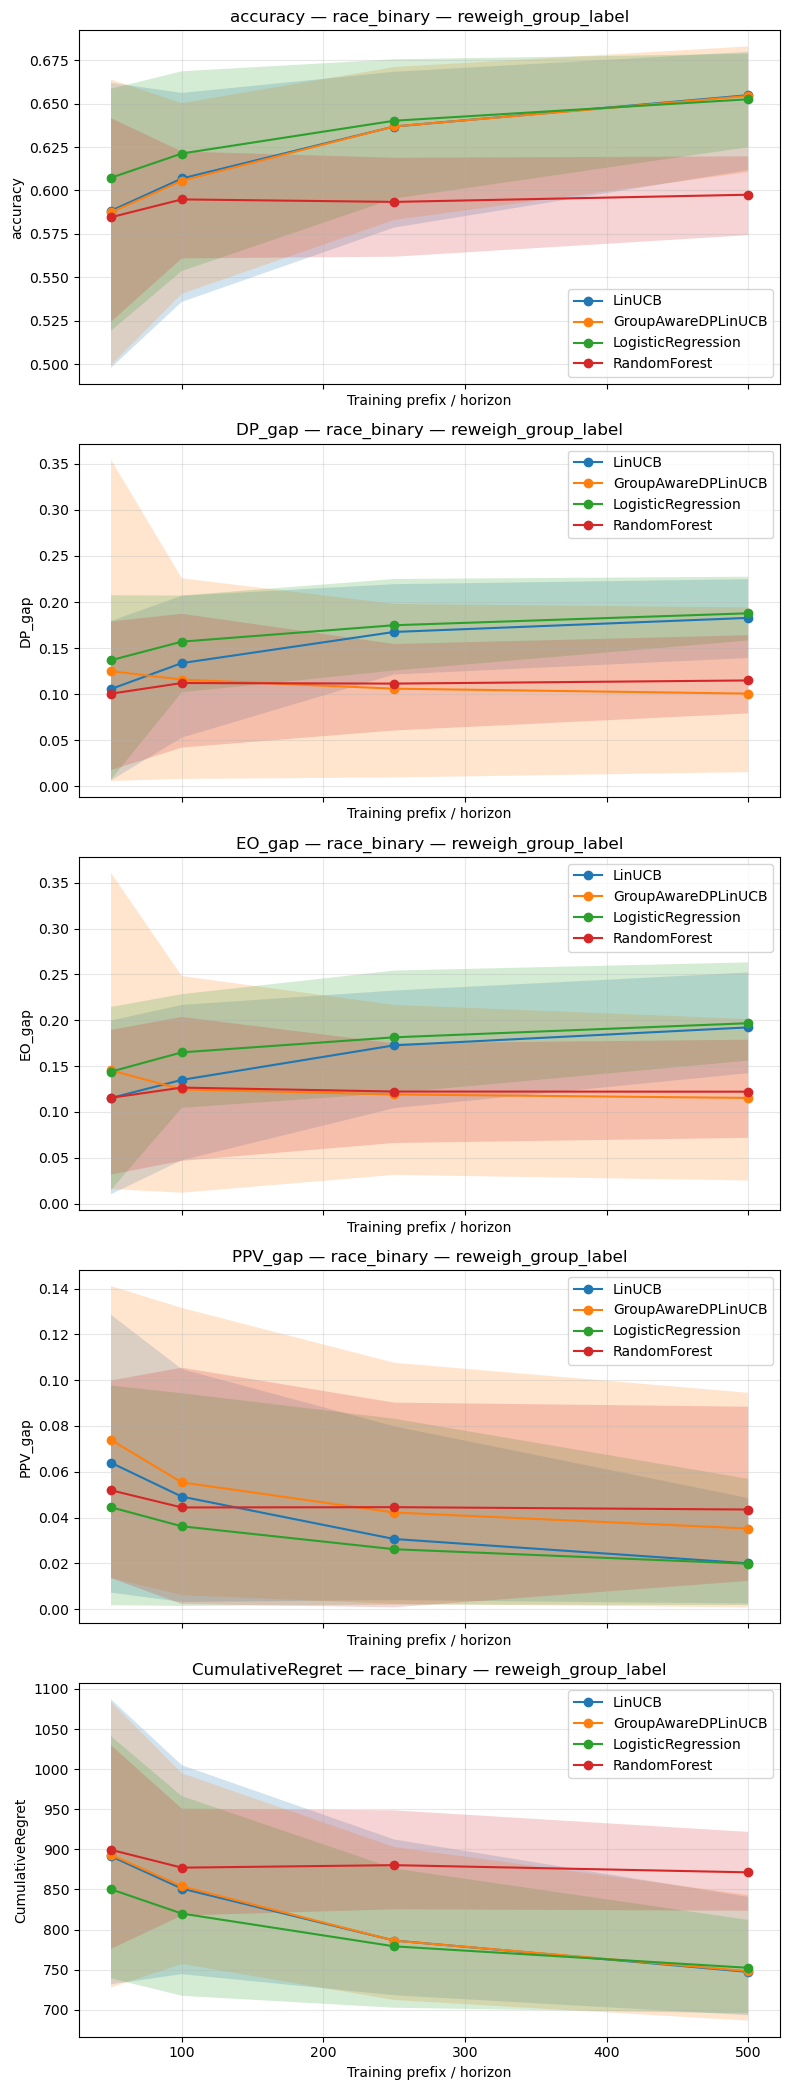

In [8]:
def plot_metric_across_horizons(
    ci_df: pd.DataFrame,
    *,
    metric: str,
    sensitive: str,
    preprocessing: str,
    ax=None,
    method_order: list[str] | None = None,
):
    sub = ci_df[
        (ci_df["dataset"] == DATASET_NAME) &
        (ci_df["sensitive"] == sensitive) &
        (ci_df["preprocessing"] == preprocessing) &
        (ci_df["metric"] == metric)
    ].copy()

    if sub.empty:
        raise ValueError(
            f"No data for metric={metric}, sensitive={sensitive}, preprocessing={preprocessing}"
        )

    if method_order is None:
        method_order = sub["method"].drop_duplicates().tolist()

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    for method in method_order:
        d = sub[sub["method"] == method].sort_values("horizon")
        if d.empty:
            continue
        ax.plot(d["horizon"], d["mean"], marker="o", label=method)
        ax.fill_between(d["horizon"], d["ci_low"], d["ci_high"], alpha=0.2)

    ax.set_xlabel("Training prefix / horizon")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} — {sensitive} — {preprocessing}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    return ax


PLOT_METRICS = ["accuracy", "DP_gap", "EO_gap", "PPV_gap", "CumulativeRegret"]

for sensitive in SENSITIVE_COLS:
    for preprocessing in PREPROCESSINGS:
        fig, axes = plt.subplots(len(PLOT_METRICS), 1, figsize=(8, 4.2 * len(PLOT_METRICS)), sharex=True)
        if len(PLOT_METRICS) == 1:
            axes = [axes]

        for ax, metric in zip(axes, PLOT_METRICS):
            plot_metric_across_horizons(
                snapshot_ci_long,
                metric=metric,
                sensitive=sensitive,
                preprocessing=preprocessing,
                ax=ax,
                method_order=METHOD_ORDER,
            )

        plt.tight_layout()
        plt.show()

### Statistical focus tables

In [9]:
KEY_METRICS = ["accuracy", "DP_gap", "EO_gap", "PPV_gap", "CumulativeRegret"]

focus_pairwise = snapshot_pairwise_df[
    snapshot_pairwise_df["metric"].isin(KEY_METRICS)
].copy()

if not focus_pairwise.empty:
    focus_pairwise = focus_pairwise.sort_values(
        ["sensitive", "preprocessing", "horizon", "metric", "method_a", "method_b"]
    ).reset_index(drop=True)

display(focus_pairwise.head(40))

,dataset,sensitive,preprocessing,horizon,metric,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,LinUCB,50,893.160000,891.340000,1.820000,382.5,7.116042e-01,LinUCB,1.000000e+00
1,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,LogisticRegression,50,893.160000,850.160000,43.000000,242.0,1.345230e-04,LogisticRegression,5.380920e-04
2,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,GroupAwareDPLinUCB,RandomForest,50,893.160000,899.380000,-6.220000,570.0,5.146469e-01,GroupAwareDPLinUCB,1.000000e+00
3,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LinUCB,LogisticRegression,50,891.340000,850.160000,41.180000,216.5,4.818853e-05,LogisticRegression,2.409426e-04
4,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LinUCB,RandomForest,50,891.340000,899.380000,-8.040000,549.0,5.275905e-01,LinUCB,1.000000e+00
5,compas,race_binary,reweigh_group_label,50,CumulativeRegret,value,LogisticRegression,RandomForest,50,850.160000,899.380000,-49.220000,189.5,1.525344e-05,LogisticRegression,9.152065e-05
6,compas,race_binary,reweigh_group_label,50,DP_gap,value,GroupAwareDPLinUCB,LinUCB,50,0.124829,0.105484,0.019344,326.0,2.588687e-01,LinUCB,9.648810e-01
7,compas,race_binary,reweigh_group_label,50,DP_gap,value,GroupAwareDPLinUCB,LogisticRegression,50,0.124829,0.136739,-0.011910,515.0,2.412202e-01,GroupAwareDPLinUCB,9.648810e-01
8,compas,race_binary,reweigh_group_label,50,DP_gap,value,GroupAwareDPLinUCB,RandomForest,50,0.124829,0.100391,0.024438,517.0,2.490849e-01,RandomForest,9.648810e-01
9,compas,race_binary,reweigh_group_label,50,DP_gap,value,LinUCB,LogisticRegression,50,0.105484,0.136739,-0.031254,202.0,9.372739e-06,LinUCB,4.686369e-05
